In [1]:
# # 1-a dalis: ECG Denoising Pipeline test with a single .npy file from DATA/ZIVE_DATA
# Uses CONFIG/pipeline_config.yaml

from __future__ import annotations

from pathlib import Path
from typing import Iterable, Tuple
import math
import numpy as np

# --- ecg_denoising_pipeline imports (as in your original) ---
from ecg_denoising_pipeline import (
    ECGDenoisingPipeline,
    DenoisingPipelineResult,
    DenoisingPipelineConfig,
    load_denoising_config_yaml,
    check_denoising_config,
    friendly_print_denoising_cfg,
    convert_seconds_to_hms,
)

from ecg_ectopy_pipeline import resolve_model_path

# ------------- Utilities -------------

def print_heading(title: str) -> None:
    line = '-' * max(10, len(title))
    print(f'\n{title}\n{line}')

def as_seconds(
    intervals: Iterable[Tuple[int, int]], fs: float
) -> list[Tuple[float, float]]:
    """Convert sample-based intervals to seconds."""
    return [(s / fs, e / fs) for (s, e) in intervals]

def load_array_or_fail(data_dir: Path, filename: str) -> np.ndarray:
    path = (data_dir / filename).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Data file not found: {path}")
    arr = np.load(path, allow_pickle=False)
    if arr.size == 0:
        raise ValueError(f"ECG is empty: {path}")
    return arr


def list_npy_files(data_dir: Path) -> list[Path]:
    return sorted(data_dir.glob("*.npy"))


# ------------- Main flow -------------

def run_denoising_pipeline(
    file_name: str | None,
    data_dir: Path,
    config_path: Path,
    model_dir: Path,
    disable_motions: bool,
) -> tuple[DenoisingPipelineResult, DenoisingPipelineConfig]:
    # Paths sanity
    if not data_dir.exists():
        raise FileNotFoundError(f"Data folder not found: {data_dir}")
    if not config_path.exists():
        raise FileNotFoundError(f"Config file not found: {config_path}")
    if not model_dir.exists():
        raise FileNotFoundError(f"Model directory not found: {model_dir}")

    print_heading("Project paths")
    print("DATA_DIR:", data_dir)
    print("CONFIG  :", config_path)
    print("MODEL_DIR:", model_dir)

    # Load config
    cfg = load_denoising_config_yaml(str(config_path))
    fs = float(cfg.fs)

    print_heading("Denoising pipeline config")
    friendly_print_denoising_cfg(cfg)
    check_denoising_config(cfg)

    # Pick ECG file
    if file_name is None:
        files = list_npy_files(data_dir)
        if not files:
            raise FileNotFoundError(f"No .npy files in {data_dir}")
        file_path = files[0]
        file_name = file_path.name
        print(f"\nNo --file provided. Using first file found: {file_name}")
    else:
        file_path = (data_dir / file_name).resolve()

    # Load ECG
    print_heading("Input data")
    print(f"File: {file_name}")
    x = load_array_or_fail(data_dir, file_name)
    len_secs = math.ceil(len(x) / fs)
    h, m, s = convert_seconds_to_hms(len_secs)
    print(f"len(ecg): {len(x)} samples (~{len_secs:.1f} s) | {h:02d}:{m:02d}:{s:02d}")

    # Resolve model path (robust to ~ and absolute/relative)
    cfg.motions.model_name = resolve_model_path(model_dir, cfg.motions.model_name)

    if disable_motions:
        cfg.motions.enabled = False

    print_heading("UNet model")
    print("UNet model path:", cfg.motions.model_name)
    print("Motions enabled:", bool(getattr(cfg.motions, "enabled", True)))

    # Run pipeline
    pipe = ECGDenoisingPipeline(cfg)
    res = pipe.run(x, gaps_indices=[])

    return res, cfg


# start0
"""
Resolve key folders:
    - HERE: the project subfolder that contains CONFIG and sibling DATA/MODEL_UNET
    - ROOT: project root (parent of HERE)
    """
HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()  # 0_SELECT_ZIVE_DATA_2023
ROOT = HERE.parents[0]    # PROJECT_TRAIN_UNET
# HERE = HERE.parents[0]    # PROJECT_TRAIN_UNET
print("HERE:", HERE)
print("ROOT:", ROOT)

data_dir = ROOT / "DATA_ORIG" / "ecg_zive_npy"
cfg_dir = ROOT / "CONFIG" / "denoising_config.yaml"
model_dir = ROOT / "MODEL_UNET"  # PROJECT_TRAIN_UNET/MODEL_UNET

print("DATA_DIR:", data_dir)
print("CFG_DIR :", cfg_dir)
print("MODEL_DIR:", model_dir)

   # "Run ECG denoising pipeline on a single .npy ECG file.\n"
   # "If --file is not provided, the first .npy in DATA_DIR is used."

file_name = "1005_10.npy"
file_name = "1065_11.npy"

# Execute the pipeline in the notebook with explicit arguments
res_denoising, cfg_denoising = run_denoising_pipeline(
file_name=file_name,
data_dir=data_dir,
config_path=cfg_dir,
model_dir=model_dir,
disable_motions=False,
)

# Results
print_heading("Results")
print(f"len_original: {len(res_denoising.ecg_orig)}")
print(f"len_start   : {len(res_denoising.ecg_start)}")
print(f"len_denoised   : {len(res_denoising.ecg_denoised)}")

print("\nMaps (sample intervals):")
print("map_gaps    :", res_denoising.map_gaps)
print("map_outliers:", res_denoising.map_outliers)
print("map_rdropouts:", res_denoising.map_rdropouts)
print("map_motions :", res_denoising.map_motions)

print_heading("Detected intervals (in samples)")
print("Outliers (start):", res_denoising.outliers_indices_start)
print("Rdropouts (nout):", res_denoising.rdropouts_indices_nout)
print("Motions (nrd)   :", res_denoising.motions_indices_nrd)

print_heading("Detected intervals (in seconds)")
print("Outliers (start):", as_seconds(res_denoising.outliers_indices_start, cfg_denoising.fs))
print("Rdropouts (nout):", as_seconds(res_denoising.rdropouts_indices_nout, cfg_denoising.fs))
print("Motions (nrd)   :", as_seconds(res_denoising.motions_indices_nrd, cfg_denoising.fs))



2026-02-25 16:25:50.888468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772036750.896952  648494 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772036750.899592  648494 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


HERE: /home/kestutis/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/0_SELECT_ZIVE_DATA_2023
ROOT: /home/kestutis/DI/2025_ZIVEO/PROJECT_TRAIN_UNET
DATA_DIR: /home/kestutis/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/DATA_ORIG/ecg_zive_npy
CFG_DIR : /home/kestutis/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/CONFIG/denoising_config.yaml
MODEL_DIR: /home/kestutis/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/MODEL_UNET

Project paths
-------------
DATA_DIR: /home/kestutis/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/DATA_ORIG/ecg_zive_npy
CONFIG  : /home/kestutis/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/CONFIG/denoising_config.yaml
MODEL_DIR: /home/kestutis/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/MODEL_UNET

Denoising pipeline config
-------------------------
🔧 Config:
{
  "DEBUG": false,
  "fs": 200,
  "memory_lean": true,
  "filter": {
    "enabled": true,
    "method": "butterworth",
    "type": "bandpass",
    "lowcut": 0.5,
    "highcut": 70.0,
    "order": 4
  },
  "outliers": {
    "enabled": true,
    "ekg_min": -3.0,
    "ekg_max": 4.0,
    "length_fragme

2026-02-25 16:25:51.927257: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1772036752.461497  648643 service.cc:148] XLA service 0x7576480195a0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772036752.461520  648643 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1772036752.689445  648643 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Results
----------
len_original: 127999
len_start   : 127999
len_denoised   : 80000

Maps (sample intervals):
map_gaps    : IndexMap(kept=[(0, 127998, 0, 127998)])
map_outliers: IndexMap(kept=[(0, 28745, 0, 28745), (33280, 127998, 28746, 123464)])
map_rdropouts: IndexMap(kept=[(0, 123464, 0, 123464)])
map_motions : IndexMap(kept=[(3536, 9261, 0, 5725), (42388, 44469, 5726, 7807), (51273, 123464, 7808, 79999)])

Detected intervals (in samples)
-------------------------------
Outliers (start): [(28746, 33279)]
Rdropouts (nout): []
Motions (nrd)   : [(0, 3535), (9262, 42387), (44470, 51272)]

Detected intervals (in seconds)
-------------------------------
Outliers (start): [(143.73, 166.395)]
Rdropouts (nout): []
Motions (nrd)   : [(0.0, 17.675), (46.31, 211.935), (222.35, 256.36)]



Show final signal with ectopy annotations and predictions:

len(annot_df_): 92
Mapped 455 R-peaks from final -> start
rpeaks_start (len 455): 455
outliers_idx_seconds: [(143.73, 166.395)]
rdropouts_idx_seconds: []
motions_idx_seconds: [(0.0, 17.675), (46.31, 143.725), (166.4, 234.605), (245.02, 279.03)]
Fragments (s): [(0.0, 20.0), (20.0, 40.0), (40.0, 60.0), (60.0, 80.0), (80.0, 100.0), (100.0, 120.0), (120.0, 140.0), (140.0, 160.0), (160.0, 180.0), (180.0, 200.0), (200.0, 220.0), (220.0, 240.0), (240.0, 260.0), (260.0, 280.0), (280.0, 300.0), (300.0, 320.0), (320.0, 340.0), (340.0, 360.0), (360.0, 380.0), (380.0, 400.0), (400.0, 420.0), (420.0, 440.0), (440.0, 460.0), (460.0, 480.0), (480.0, 500.0), (500.0, 520.0), (520.0, 540.0), (540.0, 560.0), (560.0, 580.0), (580.0, 600.0), (600.0, 620.0), (620.0, 640.0)]


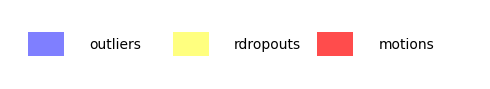


outliers-> yellow, rdropouts-> blue, motions-> red
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Unmatched annot rows: 20
Finished plotting 1065_11.npy


In [ ]:
# Vaizdavimas su annotacijomis 

# Vaizduojame signalą su ectopijomis : res.ecg_start
# naudojame rpeaks_on_start_df (pred_df) ir annot_df
# Show denoised signal with ectopy //////////////////////////////////

from __future__ import annotations

from dataclasses import dataclass
from typing import Optional
import numpy as np
import pandas as pd

import numpy.typing as npt

from ecg_denoising_pipeline import load_nonzero_annots
from ecg_denoising_pipeline import (
    plot_ecg_annot_pred,
    divide_signal_into_fragments,
    plot_gap_legend,
)
from ecg_denoising_pipeline import map_mark_denoised_to_start
# from step_beats_no_ectopy import map_rpeaks_denoised_to_start

IntArray1D = npt.NDArray[np.int_]
BoolArray1D = npt.NDArray[np.bool_]

fs = cfg_denoising.fs

flag_show_denoised_with_ectopy = True
# Show denoised signal with ectopy //////////////////////////////////

if flag_show_denoised_with_ectopy:
    
    print("\nShow final signal with ectopy annotations and predictions:")
    
    # Prepare data for plotting

    # 1. Iš išvalyto nuo triukšmų signalo randame R-peak'us rpeaks_on_denoised
    #  ir remapiname į R-peak'us į pradinį signalą
    rpeaks_on_denoised = res_ectopy.rpeaks_on_denoised_df["rpeak"].astype(int).tolist()
    rpeaks_on_start, rpeaks_on_gap = map_mark_denoised_to_start( rpeaks_on_denoised, res_denoising )
    rpeaks_on_start = np.array(rpeaks_on_start, dtype=int)

    # 2. Jei yra ectopy annotacijos,jas užkrauname
    annot_df_: Optional[pd.DataFrame] = load_nonzero_annots(data_dir, file_name)
    if annot_df_ is None:
        print("\nNo non-zero annotations found.")
    else:
        print(f"\nlen(annot_df_): {len(annot_df_)}")

    # 3. Remapiname rpeaks_on_denoised_df, gautą iš get_beats_ml_classes į start signalą
    # Build dataframe in 'start' coordinates (keeps Index and pred)
    rpeaks_on_start_df = res_ectopy.rpeaks_on_denoised_df.copy()
    rpeaks_on_start_df["rpeak"] = rpeaks_on_start

    print(f"Mapped {len(rpeaks_on_start_df)} R-peaks from final -> start")
    pred_df_ = rpeaks_on_start_df.loc[rpeaks_on_start_df["pred"].ne(0)].copy()
    if pred_df_.empty:
        pred_df_ = None

    PORTION_LENGTH_SECS = 20
    DISPLAY_AS_SECONDS = True
    SAVE_PLOTS = True
    PLOT_DIR = HERE / "PLOTS" / "ectopy_plots"
    PLOT_SUFFIX = "with_ectopy"
    fileName = "ecg_start"

    ecg_signal = res_denoising.ecg_start

    rpeaks_on_start_secs = np.array([x/fs for x in rpeaks_on_start])
    print(f"rpeaks_start (len {len(rpeaks_on_start)}): {len(rpeaks_on_start_secs)}")

    # annot_df_ = annot_df.loc[annot_df["annot"] != 0].copy()
    # pred_df = rpeaks_on_start_df
    # pred_df_ = pred_df.loc[pred_df["pred"] != 0].copy()

    # Convert outliers indices to seconds for reporting
    outliers_idx_seconds = [(s / fs, e / cfg_denoising.fs) for (s, e) in res_denoising.projected_to_start['outliers']]
    print(f"outliers_idx_seconds: {outliers_idx_seconds}")
    rdropouts_idx_seconds = [(s / fs, e / cfg_denoising.fs) for (s, e) in res_denoising.projected_to_start['rdropouts']]
    print(f"rdropouts_idx_seconds: {rdropouts_idx_seconds}")
    motions_idx_seconds = [(s / fs, e / cfg_denoising.fs) for (s, e) in res_denoising.projected_to_start['motions']]
    print(f"motions_idx_seconds: {motions_idx_seconds}")

    fragment_samples = divide_signal_into_fragments(ecg_signal, int(PORTION_LENGTH_SECS * fs))
    fragment_secs = [(start / fs, end / fs) for start, end in fragment_samples]
    print("Fragments (s):", [(round(s, 1), round(e, 1)) for s, e in fragment_secs])
 
    # Plot small rectangles and notes in one line
    plot_gap_legend('outliers', 'rdropouts', 'motions')
    print("\noutliers-> yellow, rdropouts-> blue, motions-> red")

    # gap_layers = [
    #     GapLayer(tuple(gap1_indices_secs or []), "red", 0.5),
    #     GapLayer(tuple(gap2_indices_secs or []), "blue", 0.5),
    #     GapLayer(tuple(gap3_indices_secs or []), "yellow", 0.7),
    # ]

 
    next_fragment_idx = 1
    for start_sec, end_sec in fragment_secs:
        next_fragment_idx = plot_ecg_annot_pred(
            fileName=fileName,
            ecg_signal=ecg_signal,
            fs=fs,
            plot_signal_from_in_secs=start_sec,
            plot_signal_to_in_secs=end_sec,
            portion_length_in_secs=PORTION_LENGTH_SECS,
            plot_save_dir=Path(PLOT_DIR) if SAVE_PLOTS else None,
            save_mark=PLOT_SUFFIX,
            recID=None,
            gap1_indices_secs=motions_idx_seconds, # red
            gap2_indices_secs=rdropouts_idx_seconds, # blue
            gap3_indices_secs=outliers_idx_seconds, # yellow
            rpeak_indices_secs=rpeaks_on_start_secs,
            annot_df=annot_df_,
            pred_df=pd.DataFrame(),a
            tol_samples=10,
            flag_secs=DISPLAY_AS_SECONDS,
        )

    print("Finished plotting", file_name)